<h3> RBOB gasoline </h3>
<p> In this notebook we will be performing the same thing </p>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

np.random.seed(42)

In [3]:
features = pd.read_parquet('../notebooks/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../notebooks/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

Shape: (5032, 76)
Date range: 2020-01-02 → 2022-06-30
Instruments: ['cl1s', 'gc1s', 'hg1s', 'ho1s', 'ng1s', 'pl1s', 'rb1s', 'si1s']
Feature columns: 73


In [4]:
# In this section we are extracting the the gasoline and appending to it the extracted values
gasoline = features[features['instrument'] == 'rb1s'].set_index('date').sort_index().copy()
print(gasoline.shape)
gasoline.head()

(629, 75)


,instrument,primary_signal,ret_1d,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,...,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,hmm_basket_turbulent_metals,kmeans_cluster_id,kmeans_cluster_size,primary_signal_lag1,primary_signal_lag5,primary_signal_streak,primary_signal_agreement_5d
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,rb1s,-1.0,0.008104,0.008071,-0.013522,0.010094,0.085732,0.108674,0.012117,0.015387,...,0.010851,42.0,0.999259,0.001567,0.0,0.75,NaN,NaN,0.0,NaN
2020-01-03,rb1s,0.0,0.026171,0.025834,-0.002912,0.037056,0.085484,0.127207,0.012093,0.015682,...,0.012617,43.0,0.998434,0.001323,0.0,0.75,-1.0,NaN,1.0,NaN
2020-01-06,rb1s,1.0,0.003202,0.003197,0.005544,0.026686,0.078202,0.126490,0.012006,0.015681,...,0.010814,44.0,0.999299,0.001208,1.0,0.50,0.0,NaN,0.0,NaN
2020-01-07,rb1s,1.0,-0.018354,-0.018524,-0.001045,0.008748,0.043584,0.085413,0.012636,0.015670,...,0.011530,45.0,0.999323,0.002304,0.0,0.75,1.0,NaN,1.0,NaN
2020-01-08,rb1s,1.0,-0.042620,-0.043555,-0.024977,-0.034397,-0.004453,0.032355,0.016230,0.016671,...,0.028302,46.0,0.985763,0.001970,0.0,1.00,1.0,NaN,2.0,0.4


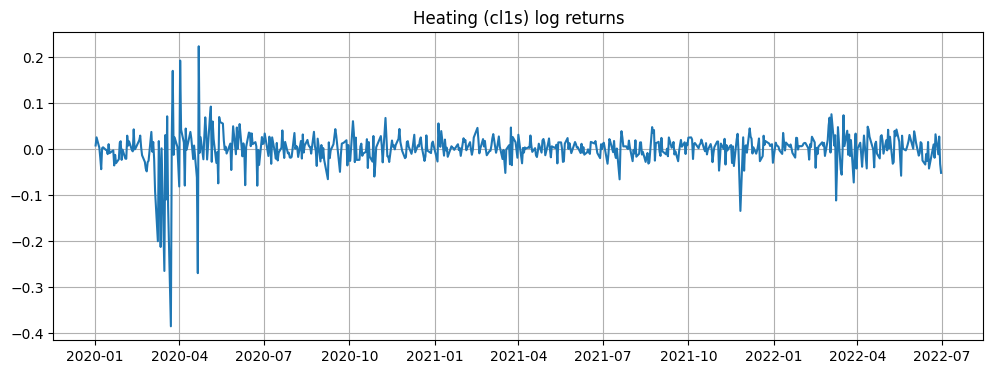

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(gasoline.index, gasoline['logret_1d'])
plt.title('Heating (cl1s) log returns')
plt.grid(True)
plt.show()

In [6]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
gasoline[base_cols].tail()

,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,parkinson_20d,garman_klass_20d,vol_of_vol_20d,...,atr_14,adx_14,dd_from_60d_high,runup_from_60d_low,days_since_60d_high,trend_tstat_10,trend_tstat_20,trend_tstat_60,trend_tstat_best,trend_H_best
date,,,,,,,,,,,,,,,,,,,,,
2022-06-24,0.032437,-0.017429,-0.095311,0.042606,0.247397,0.023396,0.026114,0.028191,0.030438,0.002229,...,0.519807,20.464032,-0.090910,0.354719,10.0,-4.020453,-1.925922,16.685882,16.685882,60.0
2022-06-27,-0.011115,0.013482,-0.081804,0.013640,0.202332,0.023268,0.025888,0.028164,0.030484,0.002186,...,0.506589,20.049497,-0.100958,0.339745,11.0,-2.770784,-3.321133,16.123140,16.123140,60.0
2022-06-28,0.027507,0.040593,-0.020935,0.010122,0.271943,0.023039,0.025370,0.028150,0.030608,0.002116,...,0.502852,19.461737,-0.075885,0.377109,12.0,-0.767852,-4.165340,15.617731,15.617731,60.0
2022-06-29,-0.031955,-0.001744,-0.042553,-0.022931,0.239163,0.024153,0.025801,0.028674,0.031169,0.002019,...,0.511485,19.224087,-0.104949,0.333799,13.0,-0.129086,-6.190523,14.635051,14.635051,60.0
2022-06-30,-0.051529,-0.034655,-0.068827,-0.113375,0.173590,0.024717,0.026739,0.029397,0.031901,0.001842,...,0.532736,20.274254,-0.149902,0.266810,14.0,-0.999693,-7.844171,13.023190,13.023190,60.0


In [7]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
gasoline[energy_cols].tail()

,energy_basket_ret_5d,energy_basket_vol_20d,rel_ret_vs_basket_5d,corr_to_basket_60d,crack_321_proxy,crack_321_z_60d,ho_cl_spread,rb_cl_spread,month_sin,month_cos,dow_sin,dow_cos,winter_indicator,driving_season
date,,,,,,,,,,,,,,
2022-06-24,-0.076530,0.031862,0.059101,0.780345,-0.007808,-0.653094,-2.152614,-1.151036,1.224647e-16,-1.0,-0.951057,0.309017,0.0,1.0
2022-06-27,-0.014179,0.032228,0.027661,0.772105,-0.035379,-2.143010,-2.200607,-1.180108,1.224647e-16,-1.0,0.000000,1.000000,0.0,1.0
2022-06-28,-0.001454,0.032284,0.042047,0.761037,-0.001817,-0.235772,-2.221490,-1.172391,1.224647e-16,-1.0,0.951057,0.309017,0.0,1.0
2022-06-29,-0.025822,0.032777,0.024078,0.767745,-0.016514,-1.046729,-2.242871,-1.186471,1.224647e-16,-1.0,0.587785,-0.809017,0.0,1.0
2022-06-30,-0.065902,0.034846,0.031247,0.785399,-0.007818,-0.562919,-2.237879,-1.200694,1.224647e-16,-1.0,-0.587785,-0.809017,0.0,1.0


In [8]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available — subsequent OVX cells will be skipped.')

OVX rows: 4789 range: 2007-05-10 → 2026-05-21


In [10]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is std of daily logret — annualise by sqrt(252) and ×100 for vol points.
    rv_pts = gasoline['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    gasoline = gasoline.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(gasoline[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

            ovx_close     ovx_z  iv_rv_ratio  ovx_slope
date                                                   
2022-06-24  46.990002 -0.948578     1.265208   0.015561
2022-06-27  46.990002 -0.974712     1.272180  -0.044724
2022-06-28  46.590000 -1.102164     1.273902   0.000644
2022-06-29  48.570000 -0.590286     1.266792  -0.008573
2022-06-30  48.900002 -0.479887     1.246249   0.006587


In [11]:
# In this section we are adding the latent cols, hmms and gmm basket the reason behing the variables has been explained in the heating oil model section
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
gasoline[latent_cols].tail()

,gmm_resp_low_vol,gmm_resp_med_vol,gmm_resp_high_vol,gmm_max_resp,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size
date,,,,,,,,,,,
2022-06-24,0.838739,0.161075,0.000185,0.0,0.969758,0.030242,0.036352,5.0,0.999921,0.0,0.5
2022-06-27,0.833603,0.166201,0.000197,0.0,0.984036,0.015964,0.022546,6.0,0.999909,2.0,0.5
2022-06-28,0.817550,0.182222,0.000228,0.0,0.978188,0.021812,0.028201,7.0,0.999930,2.0,0.5
2022-06-29,0.827036,0.172771,0.000194,0.0,0.943797,0.056203,0.061452,8.0,0.999981,2.0,0.5
2022-06-30,0.742055,0.257643,0.000302,0.0,0.498174,0.501826,0.492314,0.0,1.000000,2.0,0.5


In [12]:
# In this section we are adding the primary signals to the heating oil model
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak', 'primary_signal_agreement_5d',
]
gasoline[sig_cols].dropna().head(10)

,primary_signal,primary_signal_lag1,primary_signal_lag5,primary_signal_streak,primary_signal_agreement_5d
date,,,,,
2020-01-09,1.0,1.0,-1.0,3.0,0.8
2020-01-10,0.0,1.0,0.0,4.0,0.8
2020-01-13,1.0,0.0,1.0,5.0,0.8
2020-01-14,-1.0,1.0,1.0,0.0,0.4
2020-01-15,1.0,-1.0,1.0,0.0,0.4
2020-01-16,0.0,1.0,1.0,1.0,0.2
2020-01-17,1.0,0.0,0.0,2.0,0.4
2020-01-21,0.0,0.0,-1.0,4.0,0.4
2020-01-22,0.0,0.0,1.0,5.0,0.2


In [13]:
SIGNAL_START = '2021-08-16'

# Pick the feature set you want to feed the downstream HMM.
# Start with the base + energy domain set; you can extend with latent/signal cols.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in §4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in gasoline.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

X = gasoline[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape)

Including OVX features: ['ovx_z', 'iv_rv_ratio', 'ovx_slope']
train: (408, 23) test: (221, 23)


In [14]:
# In this section we are doing the PCA analysis to cluster the different features obtained
scaler = StandardScaler()
X_train_wti = scaler.fit_transform(X_train)
X_test_wti  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_wti)
X_test_pca  = pca.transform(X_test_wti)

pc_cols = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
train_pca_df = pd.DataFrame(X_train_pca, index=X_train.index, columns=pc_cols)
test_pca_df  = pd.DataFrame(X_test_pca,  index=X_test.index,  columns=pc_cols)

var = pd.DataFrame({
    'PC': pc_cols,
    'ratio': pca.explained_variance_ratio_,
    'cumulative': np.cumsum(pca.explained_variance_ratio_),
})
print('PCs kept:', pca.n_components_)

PCs kept: 12


In [15]:
# In this section we are running a BIC sweep to choose the most optimal number of states and obtain the probabilities of each state.

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

K=2: BIC=13,027.7
K=3: BIC=12,385.4
K=4: BIC=12,285.6
K=5: BIC=11,684.0
Chosen K = 5


In [16]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,
2020-01-02,-1.289284,1.036842,1.169063,-0.704627,-1.010576,-0.207414,0.888643,0.978613,0.695907,0.735352,0.190697,-0.059068,1.110200e-96,1.825326e-298,1.390275e-31,1.000000,6.929687e-156
2020-01-03,-1.606843,1.001658,1.422605,-0.473064,-0.538257,0.813512,0.176378,1.246558,0.994907,1.433752,-0.705324,-0.382839,7.655083e-13,7.326083e-11,1.646857e-04,0.999835,8.404677e-63
2020-01-06,-1.631699,1.067008,1.476619,-0.422934,-0.510975,0.805817,0.524317,1.227129,0.588471,1.387190,-0.689761,-0.478852,2.416721e-12,3.333492e-11,3.562135e-04,0.999644,1.896828e-16
2020-01-07,-1.092875,1.418983,1.338795,-0.590099,-0.700158,0.651351,0.936456,0.934993,0.304373,1.085234,-0.293074,-0.183985,4.333354e-12,2.008920e-11,1.480720e-06,0.999999,3.420851e-17
2020-01-08,0.034468,2.001488,0.860530,-0.449702,-1.588523,-0.501086,1.573912,0.319333,-0.150412,0.159115,0.062071,0.716679,4.138439e-13,5.175213e-11,2.045202e-13,1.000000,7.672078e-18


In [18]:
# In this section we are performing the tripple barrier labeling for heating_oil prices
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        idx = close.index.searchsorted(t0)
        t1 = close.index[min(idx + max_hold, len(close.index) - 1)]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
wti_close = (
    ohlcv[ohlcv['instrument'] == 'cl1s']
    .set_index('date')['close']
    .sort_index()
)

heating_oil_signals = gasoline['primary_signal'].dropna()
heating_oil_labels = triple_barrier_meta_labels(wti_close, heating_oil_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(heating_oil_labels), 'win rate:', heating_oil_labels['meta_label'].mean().round(3))
heating_oil_labels.head()

labels: 369 win rate: 0.469


,exit,sigma_at_entry,primary_signal,first_touch,meta_label
entry,,,,,
2020-01-02,2020-01-03,0.011457,-1.0,sl,0
2020-01-06,2020-01-08,0.013170,1.0,sl,0
2020-01-07,2020-01-08,0.013163,1.0,sl,0
2020-01-08,2020-01-22,0.020437,1.0,sl,0
2020-01-09,2020-01-15,0.019443,1.0,sl,0


In [19]:
# Align X with labels — same pattern as your notebook
y_train = heating_oil_labels.loc[heating_oil_labels.index <  SIGNAL_START, 'meta_label']
y_test  = heating_oil_labels.loc[heating_oil_labels.index >= SIGNAL_START, 'meta_label']

X_train_wti = train_pca_df.reindex(y_train.index).dropna()
X_test_wti  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_wti.index]
y_test  = y_test.loc[X_test_wti.index]

print(X_train_wti.shape, y_train.shape)
print(X_test_wti.shape,  y_test.shape)

(238, 17) (238,)
(131, 17) (131,)


In [20]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


In [21]:
# In this section we are developing the logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_wti, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

    C penalty class_weight  mean_auc  std_auc
10.00      l2         None  0.520066 0.049182
 1.00      l1         None  0.517605 0.067513
 0.10      l2     balanced  0.515087 0.064470
 1.00      l2     balanced  0.514902 0.055608
 0.10      l2         None  0.514054 0.065675
 1.00      l2         None  0.513779 0.053321
 0.10      l1         None  0.482632 0.034737
 0.01      l2         None  0.482282 0.084718


In [22]:
# -----------------------------------------------------------------------
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.
# -----------------------------------------------------------------------
rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 1, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()

 n_estimators  max_depth  min_samples_leaf  mean_auc  std_auc
          200          5                10  0.529228 0.062382
          200          1                20  0.528826 0.042852
          100          5                 5  0.528227 0.070731
          200          5                10  0.523377 0.068489
          200          8                10  0.521765 0.065980
          100          8                 5  0.520320 0.075698
          200          5                 5  0.509955 0.078971
          100          3                 5  0.509790 0.117893


In [23]:
# In this section is the XGB boost model we will be trying multiple different parameters and try to obtain the best one.
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

scale_pos_weight = 1.20  (n_neg=130, n_pos=108)
 n_estimators  learning_rate  max_depth  subsample  scale_pos_weight  mean_auc  std_auc
          200           0.05          3        0.8          1.000000  0.519307 0.069734
          200           0.05          3        0.8          1.203704  0.513464 0.042633
          100           0.10          3        0.8          1.000000  0.511447 0.085163
          200           0.05          5        0.8          1.000000  0.509376 0.036363
          200           0.05          5        0.8          1.203704  0.507883 0.051638
          100           0.10          5        0.7          1.000000  0.506790 0.067712
          100           0.05          3        0.8          1.000000  0.503172 0.061347
          100           0.05          5        0.8          1.000000  0.485419 0.062513


In [24]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_wti, y_train)
    proba = model.predict_proba(X_test_wti)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

LR  test AUC: 0.5580
RF  test AUC: 0.5874
XGB  test AUC: 0.6152


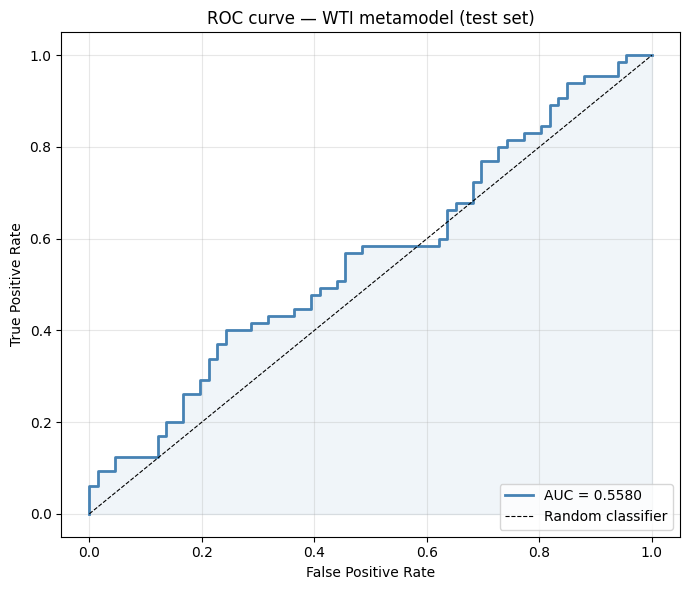

Test AUC: 0.5580


In [25]:

best_model = best_lr  # swap to best_lr or best_rf if needed

proba = best_model.predict_proba(X_test_wti)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve — WTI metamodel (test set)')

ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Test AUC: {auc:.4f}')

In [26]:
scaler_nn = StandardScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_wti.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_wti.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


input_dim=17, pos_weight=1.20


In [27]:
# In this section of the code we will be running the neural networks

# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

In [28]:
# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

In [29]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.5559 std=0.1043
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.4979 std=0.1235
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5518 std=0.0654
hidden=128 dropout=0.3 lr=0.001  mean_auc=0.6630 std=0.0618
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5600 std=0.0608
hidden=128 dropout=0.4 lr=0.0005  mean_auc=0.5744 std=0.0886

Best MLP: {'hidden_dim': 128, 'dropout': 0.3, 'lr': 0.001}


In [30]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have ~70 features
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.6038 std=0.0792
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.5112 std=0.0587
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5458 std=0.0423
hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.5115 std=0.1228
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5627 std=0.0504

Best VSN: {'hidden_dim': 32, 'dropout': 0.2, 'lr': 0.001}


In [31]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
train_cutoff = X_train_wti.index.max()
full_X_sc = pd.DataFrame(
    scaler_nn.transform(pd.concat([X_train_wti, X_test_wti]).values),
    index=pd.concat([X_train_wti, X_test_wti]).index,
    columns=X_train_wti.columns,
)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 5e-4},
    {'seq_len': 60, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 5e-4},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


seq=10 hidden=32 layers=1  mean_auc=0.5086 std=0.0510
seq=10 hidden=64 layers=2  mean_auc=0.5582 std=0.0854
seq=20 hidden=32 layers=1  mean_auc=0.4961 std=0.0553
seq=20 hidden=64 layers=2  mean_auc=0.5489 std=0.0739
seq=20 hidden=64 layers=2  mean_auc=0.5909 std=0.0819
seq=60 hidden=64 layers=2  mean_auc=0.5689 std=0.0710

Best LSTM: {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.0005}


In [32]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

MLP  test AUC: 0.5331
VSN  test AUC: 0.5375
LSTM test AUC: 0.5604


In [33]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_wti)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_wti)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_wti)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [34]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades), # Total number of trades due to labeling
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4), # The amount of trades taken
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1   auc
      0.30       119       90.8     0.5126  0.9385 0.6630 0.558
      0.35       112       85.5     0.5179  0.8923 0.6554 0.558
      0.40       101       77.1     0.5149  0.8000 0.6265 0.558
      0.45        93       71.0     0.5054  0.7231 0.5949 0.558
      0.50        80       61.1     0.4875  0.6000 0.5379 0.558
      0.55        59       45.0     0.5424  0.4923 0.5161 0.558
      0.60        39       29.8     0.6154  0.3692 0.4615 0.558
      0.65        21       16.0     0.5714  0.1846 0.2791 0.558
      0.70         8        6.1     0.7500  0.0923 0.1644 0.558
      0.75         6        4.6     0.8333  0.0769 0.1408 0.558
      0.80         1        0.8     1.0000  0.0154 0.0303 0.558

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30       131      100.0     0.4962  1.0000 0.6633 0.5874
      0.35       130       99.2     0.5000  1.0000 0.6667 0.5874
 

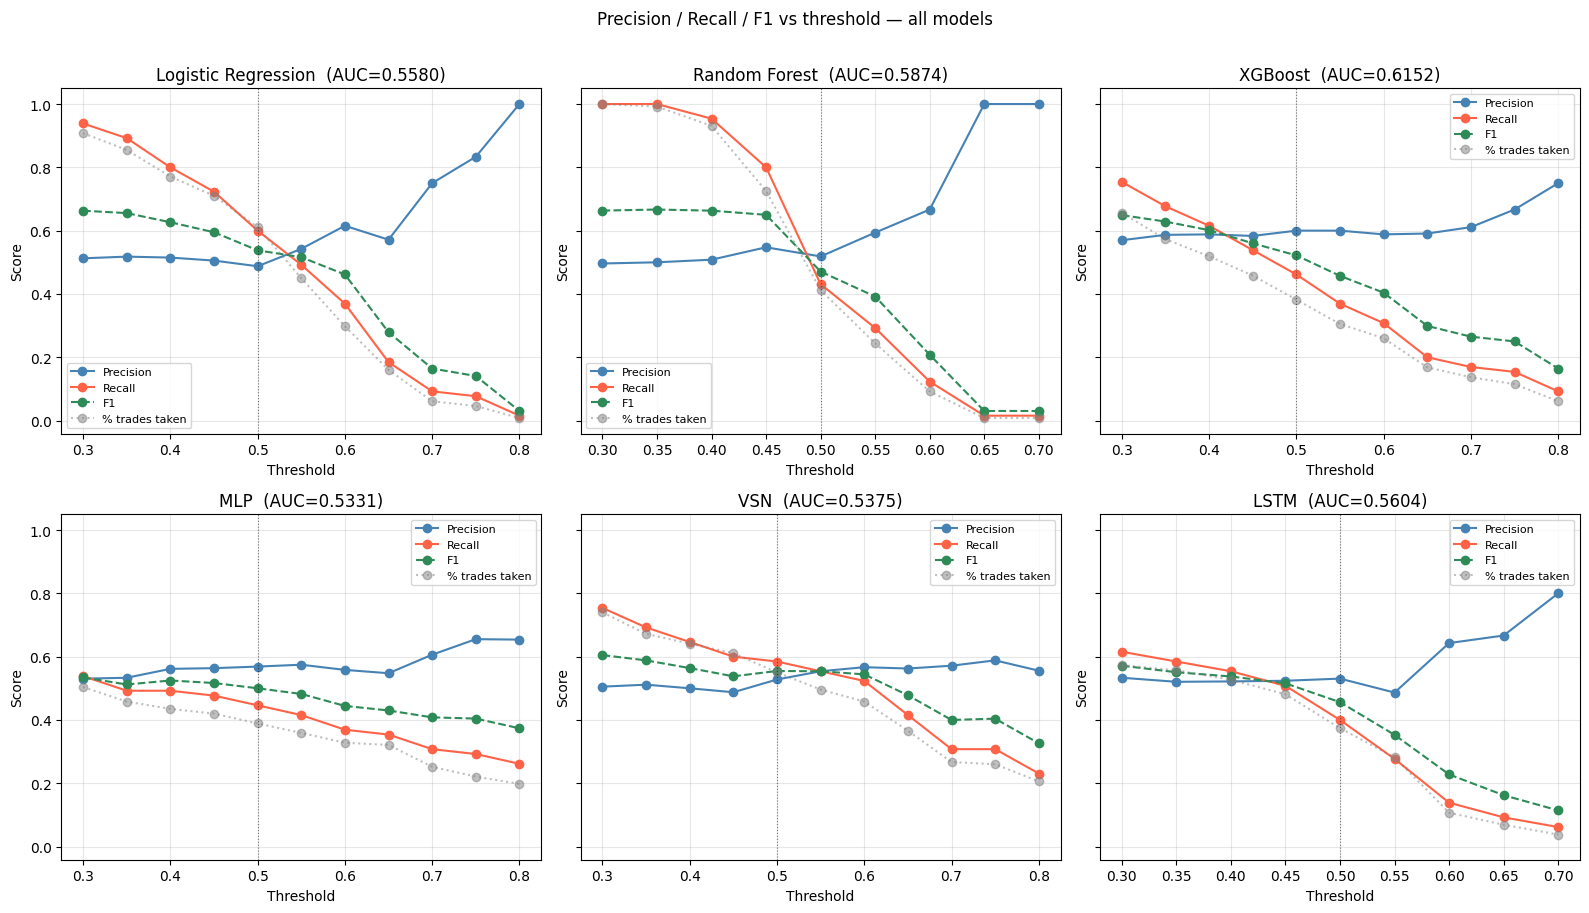

In [36]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold — all models', y=1.01)
plt.tight_layout()
plt.show()